## ✈️ Airline Booking 

![Airline booking](ticket.jpg)

This project analyzes airline booking data to understand customer preferences, booking patterns, and trip characteristics.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Data_AfterClean.xlsx")

# Booking Trends 
# - Which sales channel has the highest number of bookings? 

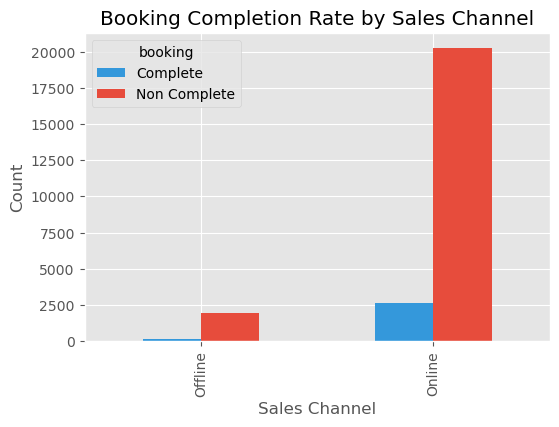

In [3]:
plt.style.use("ggplot")
pd.crosstab(df["sales_channel"], df["booking"]).plot(
    kind="bar",
    figsize=(6,4),
    color=["#3498db", "#e74c3c"]
)
plt.title("Booking Completion Rate by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Count")
plt.show()

# - How does booking completion rate vary between channels? 

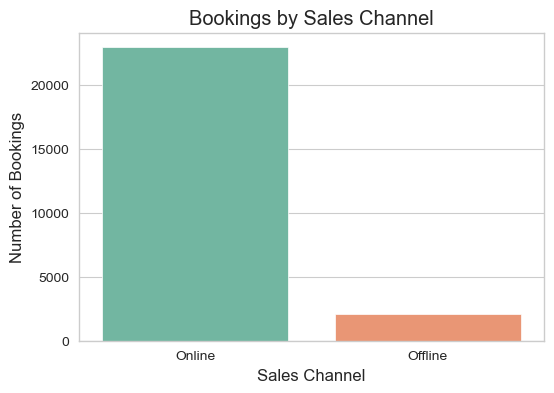

In [4]:
sns.set_style("whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sales_channel", palette="Set2")
plt.title("Bookings by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Number of Bookings")
plt.show()

# Customer Behavior 
# - What percentage of customers request extra baggage, preferred seats, or meals? 

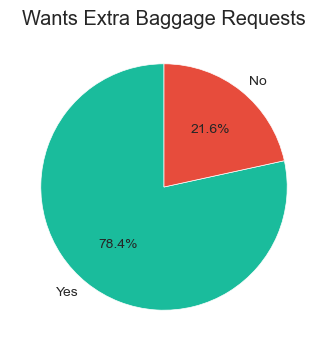

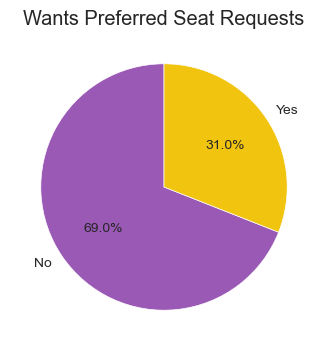

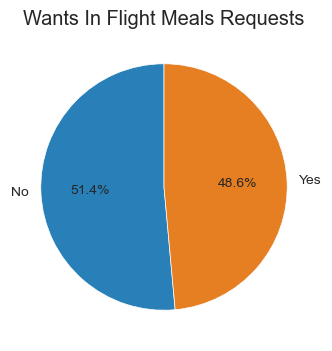

In [5]:
services = ["wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals"]
colors = [["#1abc9c","#e74c3c"], ["#9b59b6","#f1c40f"], ["#2980b9","#e67e22"]]

for i, service in enumerate(services):
    plt.figure(figsize=(4,4))
    df[service].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=90,
        colors=colors[i]
    )
    plt.title(f"{service.replace('_',' ').title()} Requests")
    plt.ylabel("")
    plt.show()

# - What is the most common trip type? 

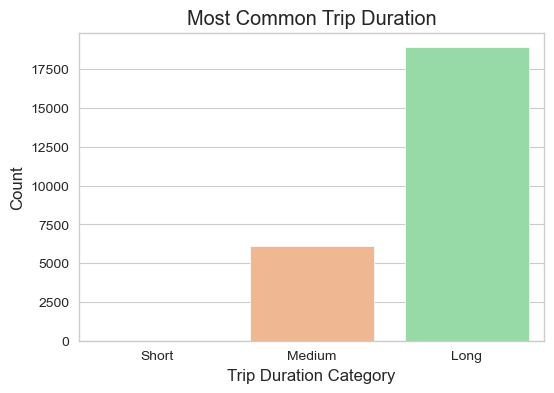

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="trip_duration_category", order=["Short","Medium","Long"], palette="pastel")
plt.title("Most Common Trip Duration")
plt.xlabel("Trip Duration Category")
plt.ylabel("Count")
plt.show()

# Timing Analysis 
# - What is the average purchase lead time? 

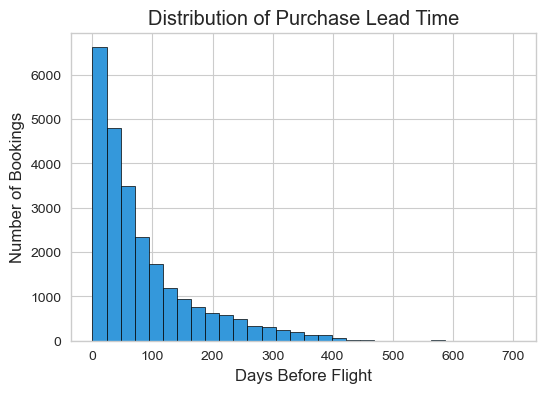

In [7]:
plt.style.use("fast")
plt.figure(figsize=(6,4))
plt.hist(df["purchase_lead"], bins=30, color="#3498db", edgecolor="black")
plt.title("Distribution of Purchase Lead Time")
plt.xlabel("Days Before Flight")
plt.ylabel("Number of Bookings")
plt.show()

# - Which days and hours are most popular for flight departures?

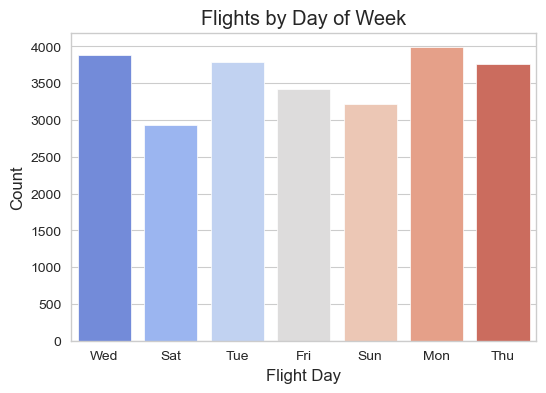

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="flight_day", palette="coolwarm")
plt.title("Flights by Day of Week")
plt.xlabel("Flight Day")
plt.ylabel("Count")
plt.show()

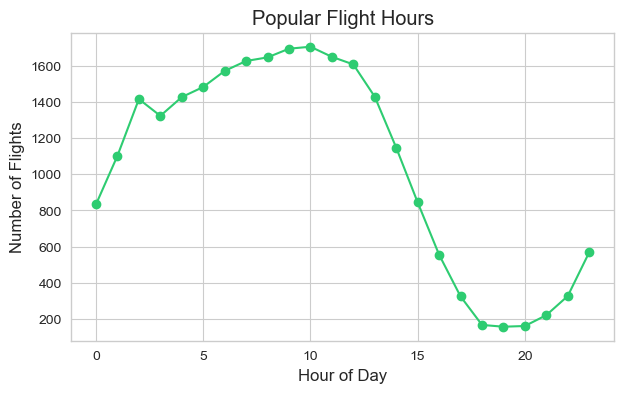

In [9]:
hour_counts = df["flight_hour"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.plot(hour_counts.index, hour_counts.values, marker="o", color="#2ecc71")
plt.title("Popular Flight Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.grid(True)
plt.show()

# Geographic Analysis 
# - Which countries have the most bookings? 

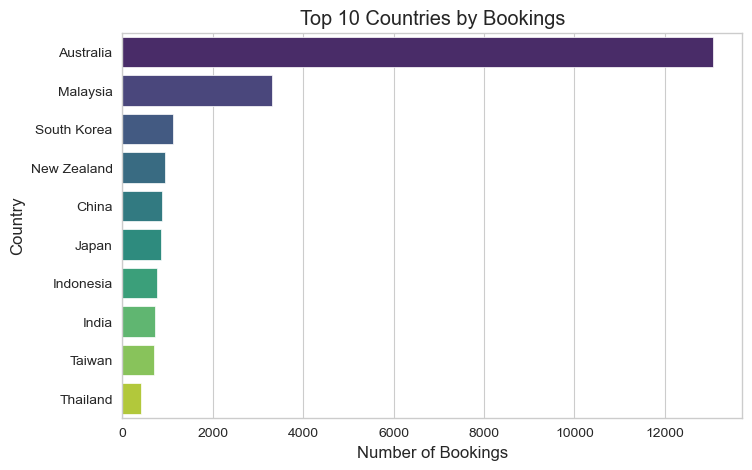

In [10]:
top_countries = df["booking_origin"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Countries by Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")
plt.show()

# - What is the average length of stay by country? 

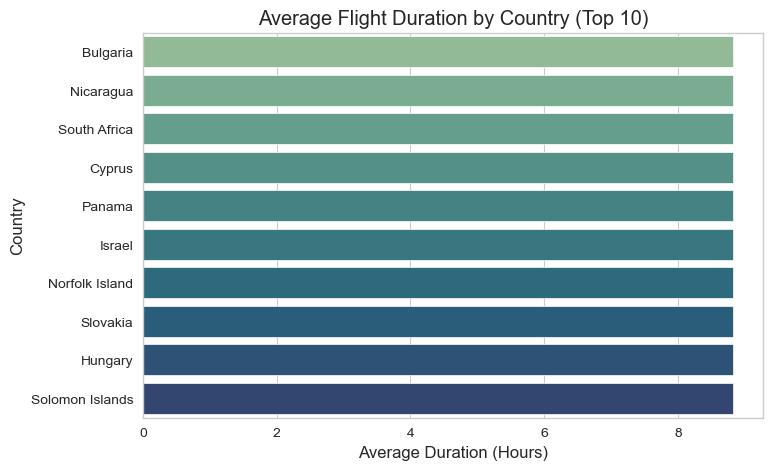

In [11]:
country_stay = df.groupby("booking_origin")["flight_duration"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=country_stay.values, y=country_stay.index, palette="crest")
plt.title("Average Flight Duration by Country (Top 10)")
plt.xlabel("Average Duration (Hours)")
plt.ylabel("Country")
plt.show()

# Performance Metrics 
# - Average passengers per booking 

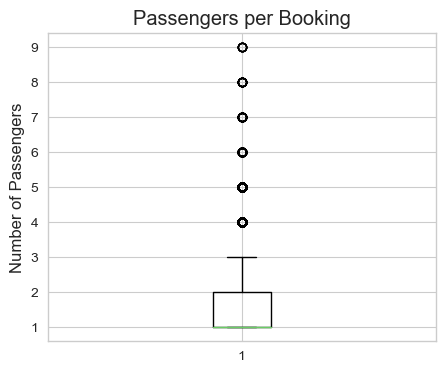

In [12]:
plt.style.use("seaborn-v0_8-muted")
plt.figure(figsize=(5,4))
plt.boxplot(df["num_passengers"])
plt.title("Passengers per Booking")
plt.ylabel("Number of Passengers")
plt.show()

# - Average flight duration per trip type 

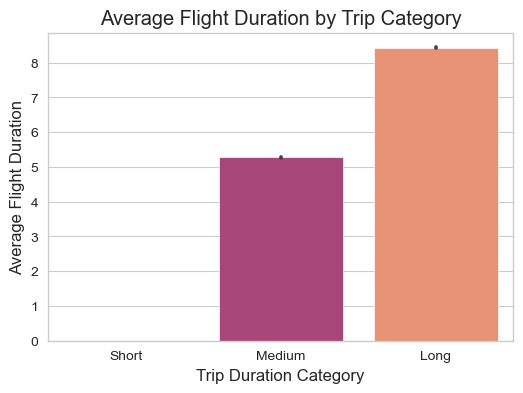

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="trip_duration_category", y="flight_duration", order=["Short","Medium","Long"], palette="magma")
plt.title("Average Flight Duration by Trip Category")
plt.xlabel("Trip Duration Category")
plt.ylabel("Average Flight Duration")
plt.show()


# Correlation Heatmap of Numerical Features

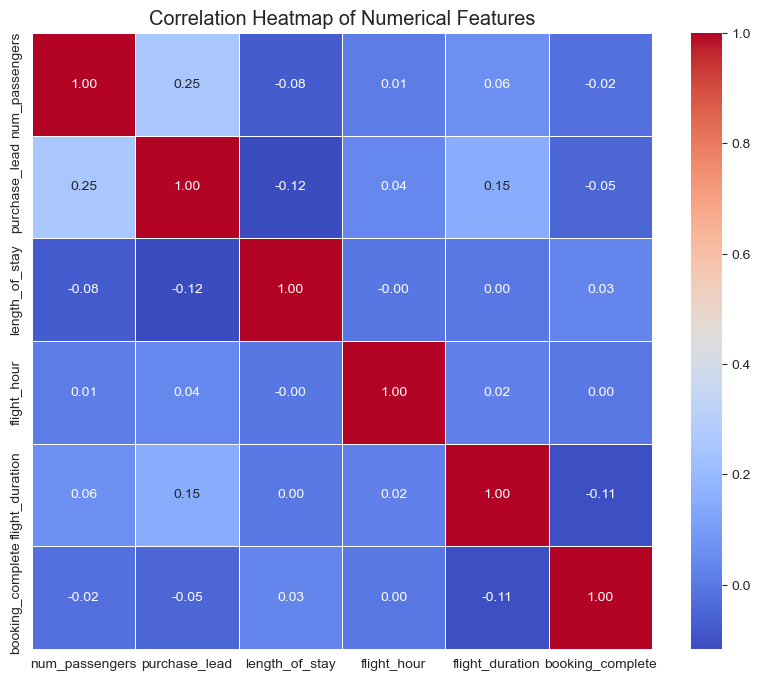

In [14]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.set_style("white")
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()